# 4 — Convergence diagnostics, and SR vs Adam

Two things that are easy to get wrong: deciding a run has converged, and getting
stochastic reconfiguration to descend at all.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import optax

In [2]:
import tempfile
from qvarnet import VMC, SamplingConfig, TrainingConfig
from qvarnet.ansatz.compose import LogWavefunction
from qvarnet.ansatz.envelopes import GaussianEnvelope
from qvarnet.ansatz.mlp import MLP
from qvarnet.physics.hamiltonian.continuous import HarmonicOscillatorHamiltonian

N = 4
E_exact = N / 2

def make_psi():
    return LogWavefunction(
        network=MLP(hidden=[32, 32], output_dim=1),
        envelope=GaussianEnvelope(),
    )

def run(optimizer, n_epochs, *, use_qgt=False, qgt_config=None, callbacks=None):
    return VMC(
        shape=(256, N), model=make_psi(), optimizer=optimizer,
        hamiltonian=HarmonicOscillatorHamiltonian(omega=1.0),
        training_config=TrainingConfig(
            n_epochs=n_epochs, rng_seed=0, checkpoint_path=tempfile.mkdtemp(),
            use_qgt=use_qgt, print_summary=False,
        ),
        sampler_params=SamplingConfig(step_size=0.5, chain_length=21,
                                      thermalization_steps=20, thinning_factor=1),
        qgt_config=qgt_config, callbacks=callbacks,
    ).run()

## The three referees

A run is converged only when all three agree. Full explanation in
`docs/explainers/convergence-diagnostics.md`.

| referee | question | reading it |
|---|---|---|
| stationary | has the energy stopped going anywhere? | Geweke \|z\| < 3 **and** Heidelberger–Welch \|t\| < 2. A negative HW slope means still improving |
| at MC floor | is the leftover wobble sampling noise, or a stalled optimiser? | tail \|E − E_best\| within ~2 error bars |
| chains mixed | are all walkers sampling the same distribution? | split-R̂ ≤ 1.1 |

In [3]:
from qvarnet.analysis import format_verdict, three_referee_verdict

short = run(optax.adam(3e-3), 60)
long_ = run(optax.adam(3e-3), 600)

for label, res in [("60 epochs", short), ("600 epochs", long_)]:
    print(f"===== {label} =====")
    print(format_verdict(three_referee_verdict(res.history)))
    print()

===== 60 epochs =====
three-referee verdict
  1. stationary    : FAIL  (|z|=14.66 < z_thr, |t|=6.00 < t_thr)
  2. at MC floor   : FAIL  (tail |E-E_best|=2.33e+00 vs err=5.97e-01)
  3. chains mixed  : FAIL  (split-R̂=1.115)
  tail energy      : 14.893741
  => NOT converged

===== 600 epochs =====
three-referee verdict
  1. stationary    : FAIL  (|z|=13.47 < z_thr, |t|=5.86 < t_thr)
  2. at MC floor   : FAIL  (tail |E-E_best|=1.63e-01 vs err=4.50e-02)
  3. chains mixed  : PASS  (split-R̂=1.005)
  tail energy      : 2.120782
  => NOT converged



Both fail, for different reasons — and notice the 60-epoch run also fails referee 3,
because the chains have not yet mixed.

The individual statistics:

In [4]:
from qvarnet.analysis import geweke_z, heidelberger_welch_t, iat_geyer, split_rhat

for label, res in [("60 epochs", short), ("600 epochs", long_)]:
    e = np.asarray(res.history.get("energy"))
    tail = e[len(e)//2:]
    chains = np.asarray(res.history.get("E_chain"))[len(e)//2:].T
    print(f"{label:12s} geweke z = {geweke_z(tail):+7.2f}   "
          f"HW t = {heidelberger_welch_t(tail):+7.2f}   "
          f"tau_int = {iat_geyer(tail):6.2f}   "
          f"split-Rhat = {split_rhat(chains):.4f}")

60 epochs    geweke z =  +14.66   HW t =   -6.00   tau_int =   9.07   split-Rhat = 1.1152
600 epochs   geweke z =  +13.47   HW t =   -5.86   tau_int =  62.49   split-Rhat = 1.0045


`tau_int` is why the referees deflate their sample counts: at `tau_int = 60`, a
300-epoch tail carries about 5 independent observations, not 300.

## Stochastic reconfiguration

SR preconditions the gradient with the inverse quantum geometric tensor, `S^-1 grad E`,
so steps are measured in distance between *wavefunctions* rather than between parameter
vectors.

The thing to internalise: **SR is a preconditioner, not an optimizer.** The optimizer
you pass is still the update rule — `optax.sgd(eta)` gives classic SR.

Adam  tail E = 2.1685 (exact 2.0)   tail sigma_E = 0.8750
SR    tail E = 2.0003 (exact 2.0)   tail sigma_E = 0.0362


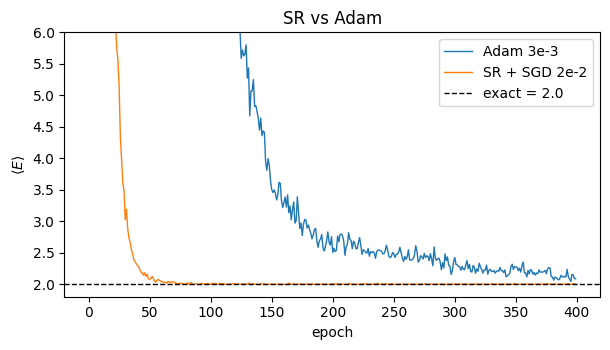

In [5]:
from qvarnet.optim import QGTConfig

qgt = QGTConfig(
    solver="auto",           # minSR when P > M, else cholesky
    learning_rate=2e-2,
    regularization=1e-2,
    max_state_change=0.1,    # the Fisher trust region: the spike guard
)

sr = run(optax.sgd(2e-2), 400, use_qgt=True, qgt_config=qgt)
adam = run(optax.adam(3e-3), 400)

plt.figure(figsize=(6.2, 3.6))
plt.plot(adam.history.get("energy"), lw=1, label="Adam 3e-3")
plt.plot(sr.history.get("energy"), lw=1, label="SR + SGD 2e-2")
plt.axhline(E_exact, color="k", ls="--", lw=1, label=f"exact = {E_exact}")
plt.xlabel("epoch"); plt.ylabel(r"$\langle E \rangle$")
plt.ylim(1.8, 6); plt.legend(); plt.title("SR vs Adam"); plt.tight_layout()

for label, r in [("Adam", adam), ("SR", sr)]:
    e = np.asarray(r.history.get("energy")); s = np.asarray(r.history.get("std"))
    print(f"{label:5s} tail E = {e[-50:].mean():.4f} (exact {E_exact})   "
          f"tail sigma_E = {s[-50:].mean():.4f}")

SR lands on the exact energy with a local-energy spread an order of magnitude smaller.

## A case worth reading carefully

Now run the referees on that SR result:

In [6]:
v = three_referee_verdict(sr.history)
print(format_verdict(v))

three-referee verdict
  1. stationary    : PASS  (|z|=0.50 < z_thr, |t|=0.08 < t_thr)
  2. at MC floor   : FAIL  (tail |E-E_best|=7.33e-03 vs err=2.27e-03)
  3. chains mixed  : PASS  (split-R̂=1.000)
  tail energy      : 2.000139
  => NOT converged


Referees 1 and 3 pass, referee 2 does not — on a run whose energy matches the exact
answer to four decimals. Referee 2 is being conservative, and it is worth seeing why:

In [7]:
e = np.asarray(sr.history.get("energy"))
tail = e[len(e)//2:]
err = v["tail_error_of_mean"]

print(f"tail mean          = {tail.mean():.6f}")
print(f"best single epoch  = {e.min():.6f}   <- the minimum over {len(e)} noisy epochs")
print(f"error of the mean  = {err:.2e}")
print(f"gap, in error bars = {(tail.mean() - e.min()) / err:.1f}")
print(f"tail scatter       = {tail.std():.2e}")

tail mean          = 2.000139
best single epoch  = 1.992812   <- the minimum over 400 noisy epochs
error of the mean  = 2.27e-03
gap, in error bars = 3.2
tail scatter       = 2.97e-03


`E_best` is the *minimum* over hundreds of noisy epochs, so it sits several error bars
below the tail mean purely as an order statistic. Referee 2 measures the tail against
that floor, so on a long, well-converged run it tends to say "not yet".

Two honest caveats rather than one:

1. this order-statistic bias, above;
2. separately, `error_of_mean` is the naive `sigma_E / sqrt(M)` and ignores the
   autocorrelation *within* each batch, so it is too small in general — tracked in
   `docs/adr/0001-correlated-error-estimates.md`. (For *this* run the epoch-to-epoch
   `tau_int` is ~1, so that is not what is driving the failure here.)

Treat referee 2 as a lower bound on convergence, and read it alongside `sigma_E`.

## Which guard shaped the step

With `use_qgt=True` the history carries SR guard diagnostics, so you can see *why* a step
was the size it was.

SR diagnostics recorded: ['trust_scale', 'fisher_norm', 'solve_ok', 'nat_grad_norm']
trust region binding in 7.0% of epochs (1.0 = not binding, < 1 = the step was trimmed)
failed solves (zero step taken): 0


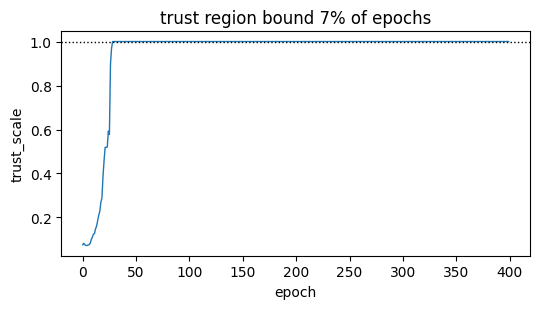

In [8]:
keys = [k for k in ("trust_scale", "fisher_norm", "solve_ok", "nat_grad_norm")
        if k in sr.history.keys()]
print("SR diagnostics recorded:", keys)

ts = np.asarray(sr.history.get("trust_scale"))
bound = float(np.mean(ts < 0.999))
plt.figure(figsize=(5.5, 3.2))
plt.plot(ts, lw=1)
plt.axhline(1.0, color="k", ls=":", lw=1)
plt.xlabel("epoch"); plt.ylabel("trust_scale")
plt.title(f"trust region bound {100*bound:.0f}% of epochs"); plt.tight_layout()

print(f"trust region binding in {100*bound:.1f}% of epochs "
      f"(1.0 = not binding, < 1 = the step was trimmed)")
print("failed solves (zero step taken):",
      int((np.asarray(sr.history.get('solve_ok')) < 0.5).sum()))

## The trap worth knowing

`grad_clip_norm` looks like the obvious spike guard. **It is not**, and enabling it is the
usual reason "SR does not descend".

The natural gradient legitimately has a huge *Euclidean* norm along flat directions of
the model — that is the entire point of the `S^-1` preconditioning. A Euclidean clip
therefore re-throttles the step the trust region just approved, by orders of magnitude.

Measured on Calogero–Sutherland: with `grad_clip_norm=10`, 100% of epochs were bound at
`|delta| ~ 3e3` and the energy went flat. With it off, SR matched Adam's descent with a
3× cleaner tail.

Use `max_state_change` (Fisher metric) as the spike guard and leave `grad_clip_norm` at
`None`. Full knob-by-knob: `docs/explainers/stochastic-reconfiguration.md`.

## Stopping automatically

`EarlyStopCallback` turns the verdict into a stop, with `n_epochs` becoming a ceiling.
Since the strict verdict rarely fires on a still-descending run, `plateau_rel` adds the
practical criterion: stop when the tail energy stops improving by a relative amount.

In [9]:
from qvarnet.callbacks import EarlyStopCallback

stopper = EarlyStopCallback(check_every=25, min_epochs=100, patience=2, plateau_rel=2e-3)
res = run(optax.adam(3e-3), 1200, callbacks=[stopper])

print(f"ran {len(res.history)} of a possible 1200 epochs")
print(f"stopped at epoch {stopper.stopped_at}, reason: {stopper.stop_reason}")
print(f"tail energy {np.asarray(res.history.get('energy'))[-50:].mean():.4f} "
      f"(exact {E_exact})")

ran 676 of a possible 1200 epochs
stopped at epoch 675, reason: plateau
tail energy 2.0448 (exact 2.0)


`reason="plateau"` means the tail improvement fell below `plateau_rel`;
`reason="verdict"` would mean all three referees passed. Which one you want depends on
whether you are chasing the last decimal or sweeping many points.